# CP8305 Final Project
## Notebook 2 – Data Preprocessing

**Team members:** Christopher Indris; Mojtaba Mohammadi; Mohammad Al Batayeh  
**Date:** 2026-03-09

---

### Instructions
Run with a fresh 3.11 environment (I used a 3.11.11 venv "cp8305fp").
Ensure that you pip install ipykernel to run the notebook.

---

### Objectives
- Remove duplicates and handle missing values.
- Detect and treat outliers.
- Encode categorical variables.
- Engineer new features using domain knowledge.
- Scale numerical features.
- Save the processed dataset for modelling.

## 1. Setup

In [1]:
%pip install --upgrade pip
%pip install ucimlrepo # for loading the dataset
%pip install scikit-learn # for data splitting and function application
%pip install matplotlib # for plotting
%pip install seaborn # for statistical plotting

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [208]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_preprocessing import (
    load_raw_data,
    drop_duplicate_rows,
    handle_missing_values,
    remove_outliers_iqr,
    encode_categoricals,
    encode_categoricals_wrapper,
    save_processed_data,
)
from src.feature_engineering import (
    PREPROCESSING_RULES,
    preprocess_numericals_for_model,
    scale_features,
    add_interaction_term,
    add_log_transform,
    add_binned_column,
)
from src.visualization import plot_count, plot_missing_values, save_figure

# Fix random seed to keep preprocessing outputs reproducible across runs.
np.random.seed(42)

sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load Data

In [209]:
data_source = 'kaggle'

In [210]:
if data_source == 'uciml':

    from ucimlrepo import fetch_ucirepo 
    
    # fetch dataset 
    diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
    
    # data (as pandas dataframes) 
    X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
    y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
    idXy = diabetes_130_us_hospitals_for_years_1999_2008.data.original
    
elif data_source == 'fairlearn':
    
    import fairlearn.datasets
    data = fairlearn.datasets.fetch_diabetes_hospital()
    
elif data_source == 'kaggle':
    
    import kagglehub
    from kagglehub import KaggleDatasetAdapter
    
    # Download latest version
    path = kagglehub.dataset_download("brandao/diabetes")
    print("Path to dataset files:", path)
    
    # df = kagglehub.load_dataset(
    #     KaggleDatasetAdapter.PANDAS,
    #     "brandao/diabetes",
    #     path + "/diabetic_data.csv",
    #     # Provide any additional arguments like 
    #     # sql_query or pandas_kwargs. See the 
    #     # documenation for more information:
    #     # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
    # )
    
    df = pd.read_csv(path + "/diabetic_data.csv")
    df.replace('?', np.nan, inplace=True)
    
    # for columns max_glu_serum and A1Cresult, make all 'NaN' values 'None'
    df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
    df['A1Cresult'] = df['A1Cresult'].fillna('None')
    
    
    idXy = df.copy()
    X = df.copy().drop(columns=['encounter_id', 'patient_nbr', 'readmitted'])
    y = df.copy()[['readmitted']]
    
else:
    df = pd.read_csv("../data/diabetes130/raw/diabetic_data.csv")
    df.replace('?', np.nan, inplace=True)
    
    # for columns max_glu_serum and A1Cresult, make all 'NaN' values 'None'
    df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
    df['A1Cresult'] = df['A1Cresult'].fillna('None')
    
    
    idXy = df.copy()
    X = df.copy().drop(columns=['encounter_id', 'patient_nbr', 'readmitted'])
    y = df.copy()[['readmitted']]

Path to dataset files: /Users/chrisindris/.cache/kagglehub/datasets/brandao/diabetes/versions/1


### Mappings for encoded values

In [211]:
def read_multiple_tables_csv(filepath, table_delimiter=',\n'):
    """
    Reads a single CSV file containing multiple tables into a list of DataFrames.
    """
    with open(filepath, "r") as f:
        csv_content = f.read()
    
    # Split the content into a list of strings, one for each table
    csv_tables_list = csv_content.split(table_delimiter)
    
    # Convert each string segment into a DataFrame
    dataframe_list = [pd.read_csv(io.StringIO(table_data)) for table_data in csv_tables_list if table_data.strip()]
    
    return dataframe_list

In [212]:
admission_type_ids, discharge_disposition_ids, admission_source_id = read_multiple_tables_csv('../data/diabetes130/raw/IDS_mapping.csv')

## 3. Remove Duplicates

There are no duplicates to drop.

In [213]:
int(X.duplicated().sum()), int(idXy.duplicated().sum())

(0, 0)

## 4. Missing Values

### Ordinal Categorical

- weight
Since weight is ordinal and categorical (weight is numeric, and it was mapped to ranges of 25 lbs.), we could estimate it by taking the mode (a kind of analogue to the mean). \
However, there may be correlations between it and other variables; in particular, age (which is ordinal categorical from a numeric, mapped to ranges of 10 years). Age also has no missing values. Hence, we could try setting for each row where weight is missing the weight equal to the mode of the weight of all rows where the age is the same as that row.

The problem is that since almost all of the weight column is missing, we can't estimate it.

NOTE: existing papers might drop the weight as well.

In [214]:
modes = X['weight'].groupby(X['age']).agg(pd.Series.mode).reset_index(drop=False)
modes['weight'] = modes['weight'].apply(lambda x: x if isinstance(x, str) else x[0])
modes

,age,weight
0,[0-10),[0-25)
1,[10-20),[50-75)
2,[20-30),[50-75)
3,[30-40),[75-100)
4,[40-50),[75-100)
5,[50-60),[75-100)
6,[60-70),[75-100)
7,[70-80),[75-100)
8,[80-90),[50-75)
9,[90-100),[50-75)


In [215]:
modes.loc[modes['age'] == '[0-10)', 'weight'].values[0]

'[0-25)'

However, some of them like A1Cresult and max_glu_serum, it is unclear what we would fill those values with. Also, we shouldn't need to make them explicitly ordinal; our ML functions will decide on how each of the values correlate with the output (especially since there are only a few different classes for each of A1Cresult and max_glu_serum)

In [217]:
# calculate which columns have missing values; we will take the union of those listed in the UCI metadata and those calculated here, so that we don't miss any

# computed directly
mvs = idXy.isna().sum().reset_index(name='missing_values')
mvs = mvs[mvs['missing_values'] > 0]['index'].tolist()

# using metadata
if data_source == 'uciml':
    mvs_meta = diabetes_130_us_hospitals_for_years_1999_2008.variables[diabetes_130_us_hospitals_for_years_1999_2008.variables.missing_values == 'yes'].name.tolist()
else:
    mvs_meta = [] # would pick up A1Cresult and max_glu_serum

columns_with_missing_values = list(set(mvs).union(set(mvs_meta)))
columns_with_missing_values

['diag_3',
 'medical_specialty',
 'weight',
 'diag_2',
 'payer_code',
 'race',
 'diag_1']

In [220]:
idXy[columns_with_missing_values].isna().sum()

diag_3                1423
medical_specialty    49949
weight               98569
diag_2                 358
payer_code           40256
race                  2273
diag_1                  21
dtype: int64

In [222]:
# the first 5 rows all have missing weight
idXy[['encounter_id', 'patient_nbr', 'weight', 'age']].head()

,encounter_id,patient_nbr,weight,age
0,2278392,8222157,NaN,[0-10)
1,149190,55629189,NaN,[10-20)
2,64410,86047875,NaN,[20-30)
3,500364,82442376,NaN,[30-40)
4,16680,42519267,NaN,[40-50)


In [223]:
def replace_missing_values(df, columns, replace_with):
    if isinstance(columns, tuple):
        columns, helper_columns = columns
    if replace_with == 'mode':
        for col in columns:
            df[col] = df[col].fillna(df[col].mode().values[0], inplace=False)
    elif replace_with == 'mode_based_on_helper_column':
        for col in columns:
            modes = df[col].groupby(df[helper_columns[0]]).agg(pd.Series.mode).reset_index(drop=False)
            modes[col] = modes[col].apply(lambda x: x if isinstance(x, str) else x[0])
            df[col] = df.apply(lambda row: modes.loc[modes[helper_columns[0]] == row[helper_columns[0]], col].values[0] if pd.isna(row[col]) else row[col], axis=1)
    return df

In [224]:
idXy = replace_missing_values(idXy, (['weight'], ['age']), 'mode_based_on_helper_column')
X = replace_missing_values(X, (['weight'], ['age']), 'mode_based_on_helper_column')

In [225]:
idXy['weight'].value_counts(dropna=False)

weight
[75-100)     78129
[50-75)      22517
[100-125)      625
[0-25)         204
[125-150)      145
[25-50)         97
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

In [226]:
# the weight have been fixed according to our mapping
idXy[['encounter_id', 'patient_nbr', 'weight', 'age']].head()

,encounter_id,patient_nbr,weight,age
0,2278392,8222157,[0-25),[0-10)
1,149190,55629189,[50-75),[10-20)
2,64410,86047875,[50-75),[20-30)
3,500364,82442376,[75-100),[30-40)
4,16680,42519267,[75-100),[40-50)


In [227]:
columns_with_missing_values.remove('weight')

In [228]:
# nearly all are missing
idXy['weight'].value_counts(dropna=False)

weight
[75-100)     78129
[50-75)      22517
[100-125)      625
[0-25)         204
[125-150)      145
[25-50)         97
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

NOTE: the "papers" on Google Drive drop the weight column because it is too sparse. 

In [229]:
# drop weight from idXy
idXy = idXy.drop(columns=['weight'])
# drop weight from X
X = X.drop(columns=['weight'])

### Nominal Categorical

These are categorical values where we cannot estimate the missing value, so we can simply say "NA".

In [230]:
idXy[columns_with_missing_values].info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   diag_3             100343 non-null  str  
 1   medical_specialty  51817 non-null   str  
 2   diag_2             101408 non-null  str  
 3   payer_code         61510 non-null   str  
 4   race               99493 non-null   str  
 5   diag_1             101745 non-null  str  
dtypes: str(6)
memory usage: 4.7 MB


In [ ]:
if data_source == 'uciml':
    diabetes_130_us_hospitals_for_years_1999_2008.variables[diabetes_130_us_hospitals_for_years_1999_2008.variables.name.isin(columns_with_missing_values)].values

array([['race', 'Feature', 'Categorical', 'Race',
        'Values: Caucasian, Asian, African American, Hispanic, and other',
        None, 'yes'],
       ['payer_code', 'Feature', 'Categorical', nan,
        'Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay',
        None, 'yes'],
       ['medical_specialty', 'Feature', 'Categorical', nan,
        'Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon',
        None, 'yes'],
       ['diag_1', 'Feature', 'Categorical', nan,
        'The primary diagnosis (coded as first three digits of ICD9); 848 distinct values',
        None, 'yes'],
       ['diag_2', 'Feature', 'Categorical', nan,
        'Secondary diagnosis (coded as first three digits of ICD9); 923 distinct values',
        None, 'yes'],
       ['diag_3', 'Feature', 'Categorical', nan,
     

array([['race', 'Feature', 'Categorical', 'Race',
        'Values: Caucasian, Asian, African American, Hispanic, and other',
        None, 'yes'],
       ['payer_code', 'Feature', 'Categorical', nan,
        'Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay',
        None, 'yes'],
       ['medical_specialty', 'Feature', 'Categorical', nan,
        'Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon',
        None, 'yes'],
       ['diag_1', 'Feature', 'Categorical', nan,
        'The primary diagnosis (coded as first three digits of ICD9); 848 distinct values',
        None, 'yes'],
       ['diag_2', 'Feature', 'Categorical', nan,
        'Secondary diagnosis (coded as first three digits of ICD9); 923 distinct values',
        None, 'yes'],
       ['diag_3', 'Feature', 'Categorical', nan,
        'Additional secondary diagnosis (coded as first three digits of ICD9); 954 distinct values',
        None, 'yes'],
       ['max_glu_serum', 'Feature', 'Categorical', nan,
        'Indicates the range of the result or if the test was not taken. Values: >200, >300, normal, and none if not measured',
        None, 'no'],
       ['A1Cresult', 'Feature', 'Categorical', nan,
        'Indicates the range of the result or if the test was not taken. Values: >8 if the result was greater than 8%, >7 if the result was greater than 7% but less than 8%, normal if the result was less than 7%, and none if not measured.',
        None, 'no']], dtype=object)

#### Race

In [231]:
idXy['race'].value_counts(dropna=False)

race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [232]:
# for column 'race' of idXy, replace nan with string "NA"
idXy['race'] = idXy['race'].fillna('NA')
# for column 'race' of X, replace nan with string "NA"
X['race'] = X['race'].fillna('NA')
idXy['race'].value_counts(dropna=False)


race
Caucasian          76099
AfricanAmerican    19210
NA                  2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

In [233]:
columns_with_missing_values.remove('race')

#### Payer Code

NOTE: it seems that lots of papers (the papers in our Google drive) drop this column due to lack of values.

In [234]:
idXy['payer_code'].value_counts(dropna=False)

payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
MP        79
SI        55
FR         1
Name: count, dtype: int64

In [235]:
# for column 'payer_code' of idXy, replace nan with string "NA"
idXy['payer_code'] = idXy['payer_code'].fillna('NA')
# for column 'payer_code' of X, replace nan with string "NA"
X['payer_code'] = X['payer_code'].fillna('NA')
idXy['payer_code'].value_counts(dropna=False)

payer_code
NA    40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

In [236]:
columns_with_missing_values.remove('payer_code')

In [237]:
# completely drop the payer_code column from idXy and X
idXy = idXy.drop(columns=['payer_code'])
X = X.drop(columns=['payer_code'])


#### Medical Specialty

NOTE: it seems that papers 5 and 7 drop these. Recent papers can either drop, or re-cardinalize. There are also many classes (73). Hence, perhaps we can drop.

In [238]:
idXy['medical_specialty'].value_counts(dropna=False)

medical_specialty
NaN                       49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
                          ...  
Dermatology                   1
SportsMedicine                1
Speech                        1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 73, dtype: int64

In [239]:
# for column 'medical_specialty' of idXy, replace nan with string "NA"
idXy['medical_specialty'] = idXy['medical_specialty'].fillna('NA')
# for column 'medical_specialty' of X, replace nan with string "NA"
X['medical_specialty'] = X['medical_specialty'].fillna('NA')
idXy['medical_specialty'].value_counts(dropna=False)

medical_specialty
NA                        49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
                          ...  
Dermatology                   1
SportsMedicine                1
Speech                        1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 73, dtype: int64

In [240]:
# completely drop the medical_specialty column from idXy and X
idXy = idXy.drop(columns=['medical_specialty'])
X = X.drop(columns=['medical_specialty'])

#### Diagnoses (1, 2, 3)

In [241]:
columns_with_missing_values.remove('medical_specialty')

In [242]:
len(idXy[idXy['diag_1'].isna()]), len(idXy[idXy['diag_2'].isna()]), len(idXy[idXy['diag_3'].isna()])

(21, 358, 1423)

In [243]:
idXy['diag_1'] = idXy['diag_1'].fillna('NA')
X['diag_1'] = X['diag_1'].fillna('NA')
idXy['diag_2'] = idXy['diag_2'].fillna('NA')
X['diag_2'] = X['diag_2'].fillna('NA')
idXy['diag_3'] = idXy['diag_3'].fillna('NA')
X['diag_3'] = X['diag_3'].fillna('NA')

columns_with_missing_values.remove('diag_1')
columns_with_missing_values.remove('diag_2')
columns_with_missing_values.remove('diag_3')


In [244]:
len(idXy[idXy['diag_1'].isna()]), len(idXy[idXy['diag_2'].isna()]), len(idXy[idXy['diag_3'].isna()])

(0, 0, 0)

In [245]:
columns_with_missing_values

[]

#### max_glu_serum

Note that in the CSV file, this is "None", not "NaN". This is because there is a difference in medical tests between "not ordered" and "not available". Hence, we can keep this in for now. (Paper 1 did not drop this column).

When we open the .csv in Excel, we see "?" for missing values and "None" as a proper category.

Hence, for this column I will use "None" rather than "NA".

In [246]:
idXy['max_glu_serum'].value_counts(dropna=False)

max_glu_serum
None    96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

In [247]:
# for column 'max_glu_serum' of idXy, replace nan with string "None" since it is a proper category
idXy['max_glu_serum'] = idXy['max_glu_serum'].fillna('None')
# for column 'max_glu_serum' of X, replace nan with string "None" since it is a proper category
X['max_glu_serum'] = X['max_glu_serum'].fillna('None')
idXy['max_glu_serum'].value_counts(dropna=False)

max_glu_serum
None    96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

In [248]:
try:
    columns_with_missing_values.remove('max_glu_serum')
except:
    pass

### A1Cresult

Note that in the CSV file, this is "None", not "NaN". This is because there is a difference in medical tests between "not ordered" and "not available". Hence, we can keep this in for now. (Paper 1 did not drop this column).

When we open the .csv in Excel, we see "?" for missing values and "None" as a proper category.

Hence, for this column I will use "None" rather than "NA".

In [249]:
idXy['A1Cresult'].value_counts(dropna=False)

A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

In [250]:
# for column 'A1Cresult' of idXy, replace nan with string "None" since it is a proper category
idXy['A1Cresult'] = idXy['A1Cresult'].fillna('None')
# for column 'A1Cresult' of X, replace nan with string "None" since it is a proper category
X['A1Cresult'] = X['A1Cresult'].fillna('None')
idXy['max_glu_serum'].value_counts(dropna=False)

max_glu_serum
None    96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

In [251]:
try:
    columns_with_missing_values.remove('A1Cresult')
except:
    pass

## 4. Modifying Data Types

In some cases, even though the data is integer (numerical ordinal), it should be treated as categorical. Examples:

- admission_type_id
- discharge_disposition_id
- admission_source_id

In [252]:
idXy.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   admission_type_id         101766 non-null  int64
 6   discharge_disposition_id  101766 non-null  int64
 7   admission_source_id       101766 non-null  int64
 8   time_in_hospital          101766 non-null  int64
 9   num_lab_procedures        101766 non-null  int64
 10  num_procedures            101766 non-null  int64
 11  num_medications           101766 non-null  int64
 12  number_outpatient         101766 non-null  int64
 13  number_emergency          101766 non-null  int64
 14  number_inpatient          10176

In [253]:
# convert the datatype of columns 'admission_type_id', 'discharge_disposition_id', 'admission_source_id' to categorical
idXy['admission_type_id'] = idXy['admission_type_id'].astype('category')
idXy['discharge_disposition_id'] = idXy['discharge_disposition_id'].astype('category')
idXy['admission_source_id'] = idXy['admission_source_id'].astype('category')

X['admission_type_id'] = X['admission_type_id'].astype('category')
X['discharge_disposition_id'] = X['discharge_disposition_id'].astype('category')
X['admission_source_id'] = X['admission_source_id'].astype('category')

idXy.info()


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101766 non-null  int64   
 1   patient_nbr               101766 non-null  int64   
 2   race                      101766 non-null  str     
 3   gender                    101766 non-null  str     
 4   age                       101766 non-null  str     
 5   admission_type_id         101766 non-null  category
 6   discharge_disposition_id  101766 non-null  category
 7   admission_source_id       101766 non-null  category
 8   time_in_hospital          101766 non-null  int64   
 9   num_lab_procedures        101766 non-null  int64   
 10  num_procedures            101766 non-null  int64   
 11  num_medications           101766 non-null  int64   
 12  number_outpatient         101766 non-null  int64   
 13  number_emergency          101766 non-nul

In [254]:
# Convert all string-type columns in idXy and X to category dtype
string_columns_idXy = idXy.select_dtypes(include=['object']).columns
for col in string_columns_idXy:
    idXy[col] = idXy[col].astype('category')
    if col in X.columns:
        X[col] = X[col].astype('category')

/var/folders/12/c9d9l3_x50qgympys7czmn0m0000gn/T/ipykernel_2205/1178708622.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_columns_idXy = idXy.select_dtypes(include=['object']).columns


In [255]:
idXy.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101766 non-null  int64   
 1   patient_nbr               101766 non-null  int64   
 2   race                      101766 non-null  category
 3   gender                    101766 non-null  category
 4   age                       101766 non-null  category
 5   admission_type_id         101766 non-null  category
 6   discharge_disposition_id  101766 non-null  category
 7   admission_source_id       101766 non-null  category
 8   time_in_hospital          101766 non-null  int64   
 9   num_lab_procedures        101766 non-null  int64   
 10  num_procedures            101766 non-null  int64   
 11  num_medications           101766 non-null  int64   
 12  number_outpatient         101766 non-null  int64   
 13  number_emergency          101766 non-nul

In [256]:
# Let's convert our IDs, 'encounter_id' and 'patient_nbr', to categorical.
idXy['encounter_id'] = idXy['encounter_id'].astype('category')
idXy['patient_nbr'] = idXy['patient_nbr'].astype('category')
idXy.info()


<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101766 non-null  category
 1   patient_nbr               101766 non-null  category
 2   race                      101766 non-null  category
 3   gender                    101766 non-null  category
 4   age                       101766 non-null  category
 5   admission_type_id         101766 non-null  category
 6   discharge_disposition_id  101766 non-null  category
 7   admission_source_id       101766 non-null  category
 8   time_in_hospital          101766 non-null  int64   
 9   num_lab_procedures        101766 non-null  int64   
 10  num_procedures            101766 non-null  int64   
 11  num_medications           101766 non-null  int64   
 12  number_outpatient         101766 non-null  int64   
 13  number_emergency          101766 non-nul

In [257]:
idXy['age'].value_counts(dropna=False)

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

age

We could add a column called "age_numeric" where [0-10) -> 0, [10-20)->1, etc. This is in the style of paper 1.

## 5. Outlier Treatment and Numeric Attribute Normalization

### Finding Outliers

In [258]:
# find the columns which are numeric (type int64); the IDs have already been converted to categorical ('encounter_id' or 'patient_nbr')
numerical_nonID_columns = idXy.select_dtypes(include=['int64'])
numerical_nonID_columns


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
0,1,41,0,1,0,0,0,1
1,3,59,0,18,0,0,0,9
2,2,11,5,13,2,0,1,6
3,2,44,1,16,0,0,0,7
4,1,51,0,8,0,0,0,5
...,...,...,...,...,...,...,...,...
101761,3,51,0,16,0,0,0,9
101762,5,33,3,18,0,0,1,9
101763,1,53,0,9,1,0,0,13
101764,10,45,2,21,0,0,1,9


In [259]:
numerical_nonID_columns = numerical_nonID_columns.columns

In [260]:
#idXy[numerical_nonID_columns].describe(include='all').T
idXy[numerical_nonID_columns].describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


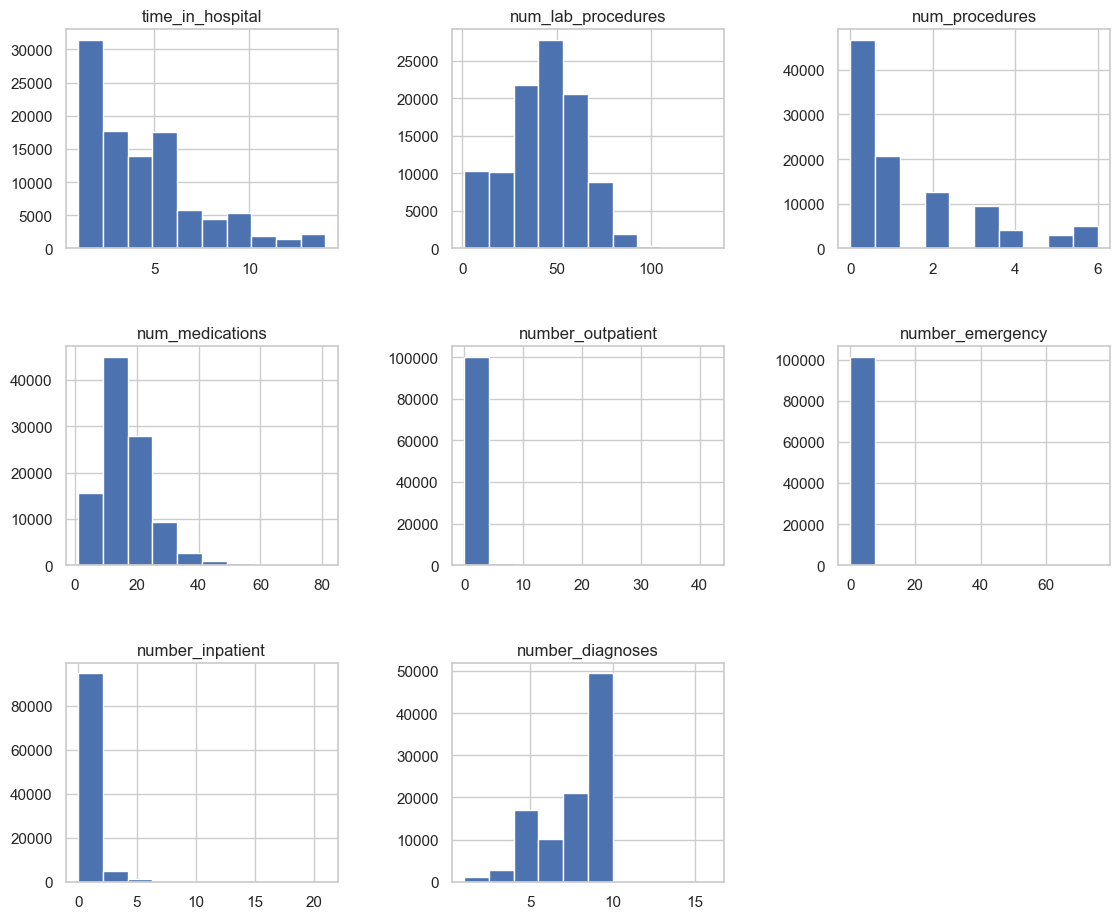

In [261]:
idXy[numerical_nonID_columns].hist(figsize=(12, 10), layout=(3, 3), sharex=False, sharey=False)
plt.tight_layout(pad=3.0)

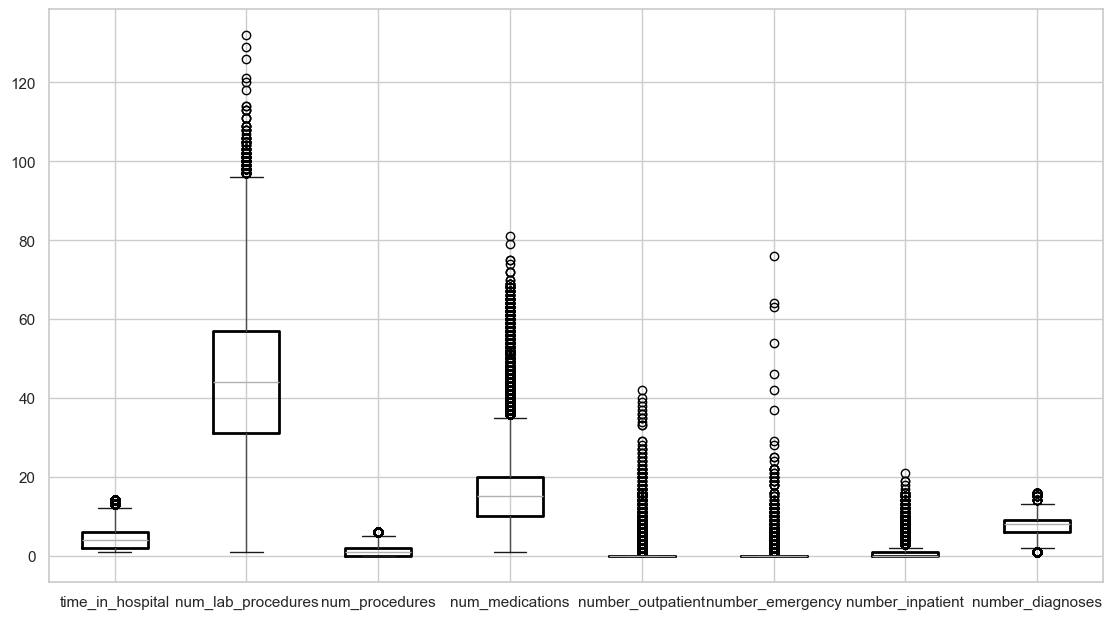

In [262]:
idXy[numerical_nonID_columns].boxplot(figsize=(12, 7), boxprops=dict(lw=2))
plt.tight_layout(pad=3.0)

In [263]:
# NOTE: we won't get rid of the outliers.

# Calculate outlier counts per numeric column based on the IQR fence.
outlier_counts = []
total_rows = idXy.shape[0]
for col in numerical_nonID_columns:
    q1 = idXy[col].quantile(0.25)
    q3 = idXy[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = idXy[(idXy[col] < lower) | (idXy[col] > upper)]
    count = outliers.shape[0]
    percent = (count / total_rows) * 100 if total_rows > 0 else 0
    outlier_counts.append({
        'column': col,
        'outlier_count': count,
        'outlier_percent': percent,
    })

outlier_counts_df = pd.DataFrame(outlier_counts).sort_values(
    by='outlier_percent', ascending=False
)
print('Number and percentage of outliers per numeric column (IQR rule):')
display(outlier_counts_df)

# -- to get rid of the outliers -- Enforce IQR filtering on the working dataset and keep X index-aligned.
# rows_before_outlier_filter = len(idXy)
# idXy = remove_outliers_iqr(idXy, list(numerical_nonID_columns))
# X = X.loc[idXy.index].copy()

print(f'Rows before outlier filtering: {rows_before_outlier_filter}')
print(f'Rows after outlier filtering : {len(idXy)}')
print(f'Rows removed                : {rows_before_outlier_filter - len(idXy)}')

Number and percentage of outliers per numeric column (IQR rule):


,column,outlier_count,outlier_percent
4,number_outpatient,16739,16.448519
5,number_emergency,11383,11.185465
6,number_inpatient,7049,6.926675
2,num_procedures,4954,4.868031
3,num_medications,2557,2.512627
0,time_in_hospital,2252,2.212920
7,number_diagnoses,281,0.276124
1,num_lab_procedures,143,0.140518


Rows before outlier filtering: 101766
Rows after outlier filtering : 101766
Rows removed                : 0


### Adjusting the Numerical Scales

In [264]:
rules_df = pd.DataFrame(PREPROCESSING_RULES).T
rules_df.index.name = "column"
print("Model-specific preprocessing rules for numerical columns:")
display(rules_df)

Model-specific preprocessing rules for numerical columns:


,knn,decision_tree,logistic_regression,gaussian_nb
column,,,,
time_in_hospital,standardize,none,standardize,optional_log1p
num_lab_procedures,standardize,none,standardize,none
num_procedures,log1p_then_standardize,none,log1p_then_standardize,log1p
num_medications,standardize,none,standardize,none
number_outpatient,log1p_then_standardize,none,log1p_then_standardize,log1p
number_emergency,log1p_then_standardize,none,log1p_then_standardize,log1p
number_inpatient,log1p_then_standardize,none,log1p_then_standardize,log1p
number_diagnoses,standardize,none,standardize,none


In [265]:
model_types = ["knn", "decision_tree", "logistic_regression", "gaussian_nb"]
cols = list(PREPROCESSING_RULES.keys())

for model_type in model_types:
    transformed_df, fitted = preprocess_numericals_for_model(idXy, model_type)

    before_stats = idXy[cols].describe().loc[["mean", "std", "min", "max"]].T
    after_stats = transformed_df[cols].describe().loc[["mean", "std", "min", "max"]].T

    summary = before_stats.join(after_stats, lsuffix="_before", rsuffix="_after")
    summary.columns = [
        "mean_before", "std_before", "min_before", "max_before",
        "mean_after", "std_after", "min_after", "max_after",
    ]

    transforms_used = {
        c: PREPROCESSING_RULES[c].get(model_type, "none") for c in cols
    }
    summary.insert(0, "transform", [transforms_used[c] for c in summary.index])

    print(f"\n{'=' * 80}")
    print(f"Model: {model_type}")
    print(f"{'=' * 80}")
    display(summary.round(4))


Model: knn


,transform,mean_before,std_before,min_before,max_before,mean_after,std_after,min_after,max_after
time_in_hospital,standardize,4.3960,2.9851,1.0,14.0,0.0,1.0,-1.1376,3.2173
num_lab_procedures,standardize,43.0956,19.6744,1.0,132.0,0.0,1.0,-2.1396,4.5188
num_procedures,log1p_then_standardize,1.3397,1.7058,0.0,6.0,-0.0,1.0,-0.9514,2.0239
num_medications,standardize,16.0218,8.1276,1.0,81.0,-0.0,1.0,-1.8483,7.9948
number_outpatient,log1p_then_standardize,0.3694,1.2673,0.0,42.0,-0.0,1.0,-0.4009,8.3594
number_emergency,log1p_then_standardize,0.1978,0.9305,0.0,76.0,-0.0,1.0,-0.3236,13.4679
number_inpatient,log1p_then_standardize,0.6356,1.2629,0.0,21.0,-0.0,1.0,-0.6385,5.4094
number_diagnoses,standardize,7.4226,1.9336,1.0,16.0,0.0,1.0,-3.3216,4.4360



Model: decision_tree


,transform,mean_before,std_before,min_before,max_before,mean_after,std_after,min_after,max_after
time_in_hospital,none,4.3960,2.9851,1.0,14.0,4.3960,2.9851,1.0,14.0
num_lab_procedures,none,43.0956,19.6744,1.0,132.0,43.0956,19.6744,1.0,132.0
num_procedures,none,1.3397,1.7058,0.0,6.0,1.3397,1.7058,0.0,6.0
num_medications,none,16.0218,8.1276,1.0,81.0,16.0218,8.1276,1.0,81.0
number_outpatient,none,0.3694,1.2673,0.0,42.0,0.3694,1.2673,0.0,42.0
number_emergency,none,0.1978,0.9305,0.0,76.0,0.1978,0.9305,0.0,76.0
number_inpatient,none,0.6356,1.2629,0.0,21.0,0.6356,1.2629,0.0,21.0
number_diagnoses,none,7.4226,1.9336,1.0,16.0,7.4226,1.9336,1.0,16.0



Model: logistic_regression


,transform,mean_before,std_before,min_before,max_before,mean_after,std_after,min_after,max_after
time_in_hospital,standardize,4.3960,2.9851,1.0,14.0,0.0,1.0,-1.1376,3.2173
num_lab_procedures,standardize,43.0956,19.6744,1.0,132.0,0.0,1.0,-2.1396,4.5188
num_procedures,log1p_then_standardize,1.3397,1.7058,0.0,6.0,-0.0,1.0,-0.9514,2.0239
num_medications,standardize,16.0218,8.1276,1.0,81.0,-0.0,1.0,-1.8483,7.9948
number_outpatient,log1p_then_standardize,0.3694,1.2673,0.0,42.0,-0.0,1.0,-0.4009,8.3594
number_emergency,log1p_then_standardize,0.1978,0.9305,0.0,76.0,-0.0,1.0,-0.3236,13.4679
number_inpatient,log1p_then_standardize,0.6356,1.2629,0.0,21.0,-0.0,1.0,-0.6385,5.4094
number_diagnoses,standardize,7.4226,1.9336,1.0,16.0,0.0,1.0,-3.3216,4.4360



Model: gaussian_nb


,transform,mean_before,std_before,min_before,max_before,mean_after,std_after,min_after,max_after
time_in_hospital,optional_log1p,4.3960,2.9851,1.0,14.0,1.5430,0.5342,0.6931,2.7081
num_lab_procedures,none,43.0956,19.6744,1.0,132.0,43.0956,19.6744,1.0000,132.0000
num_procedures,log1p,1.3397,1.7058,0.0,6.0,0.6222,0.6540,0.0000,1.9459
num_medications,none,16.0218,8.1276,1.0,81.0,16.0218,8.1276,1.0000,81.0000
number_outpatient,log1p,0.3694,1.2673,0.0,42.0,0.1721,0.4293,0.0000,3.7612
number_emergency,log1p,0.1978,0.9305,0.0,76.0,0.1019,0.3150,0.0000,4.3438
number_inpatient,log1p,0.6356,1.2629,0.0,21.0,0.3263,0.5111,0.0000,3.0910
number_diagnoses,none,7.4226,1.9336,1.0,16.0,7.4226,1.9336,1.0000,16.0000


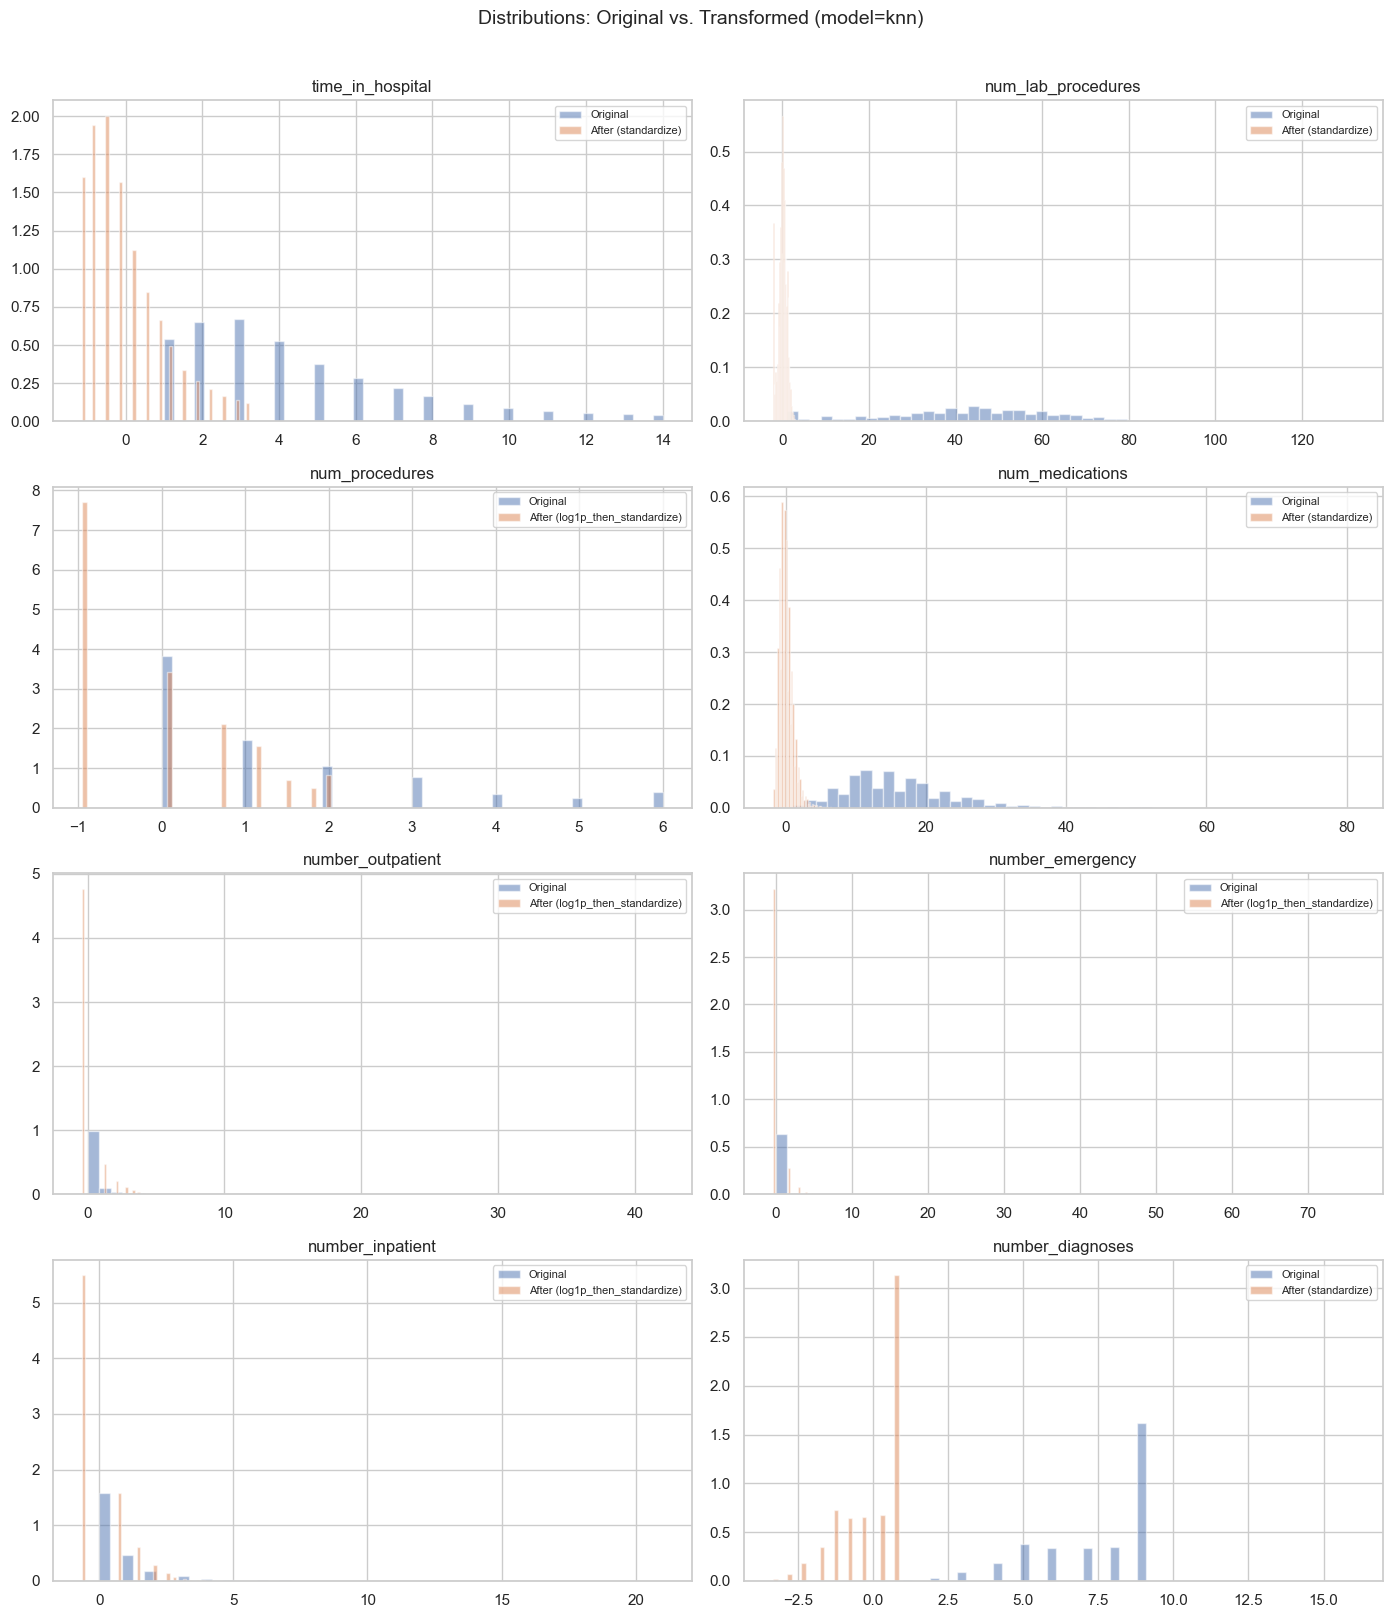

In [266]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes_flat = axes.ravel()

model_type = "knn"
transformed_df, _ = preprocess_numericals_for_model(idXy, model_type)

for i, col in enumerate(cols):
    ax = axes_flat[i]
    transform_name = PREPROCESSING_RULES[col][model_type]
    ax.hist(idXy[col], bins=50, alpha=0.5, label="Original", density=True)
    ax.hist(
        transformed_df[col], bins=50, alpha=0.5,
        label=f"After ({transform_name})", density=True,
    )
    ax.set_title(col)
    ax.legend(fontsize=8)

fig.suptitle(
    f"Distributions: Original vs. Transformed (model={model_type})",
    fontsize=14, y=1.01,
)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

### 6.1 Diagnosis Consolidation

In [267]:
# Strack-style ICD-9 collapse to 9 high-level categories used in the literature.
def icd9_to_strack_group(code):
    if pd.isna(code):
        return "Other"

    code_str = str(code).strip()
    if code_str in {"", "?", "nan", "NA"}:
        return "Other"

    code_upper = code_str.upper()
    if code_upper.startswith(("V", "E")):
        return "Other"

    try:
        value = float(code_str)
    except ValueError:
        return "Other"

    if int(value) == 250:
        return "Diabetes"
    if 390 <= value <= 459 or int(value) == 785:
        return "Circulatory"
    if 460 <= value <= 519 or int(value) == 786:
        return "Respiratory"
    if 520 <= value <= 579 or int(value) == 787:
        return "Digestive"
    if 800 <= value <= 999:
        return "Injury"
    if 710 <= value <= 739:
        return "Musculoskeletal"
    if 580 <= value <= 629 or int(value) == 788:
        return "Genitourinary"
    if 140 <= value <= 239:
        return "Neoplasms"
    return "Other"

In [268]:
for diag_col in ["diag_1", "diag_2", "diag_3"]:
    group_col = f"{diag_col}_group"
    # Keep grouped diagnoses on both frames to support diagnostics and feature engineering.
    idXy[group_col] = idXy[diag_col].apply(icd9_to_strack_group).astype("category")
    X[group_col] = X[diag_col].apply(icd9_to_strack_group).astype("category")

Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_counts_diagnosis_grouped.png


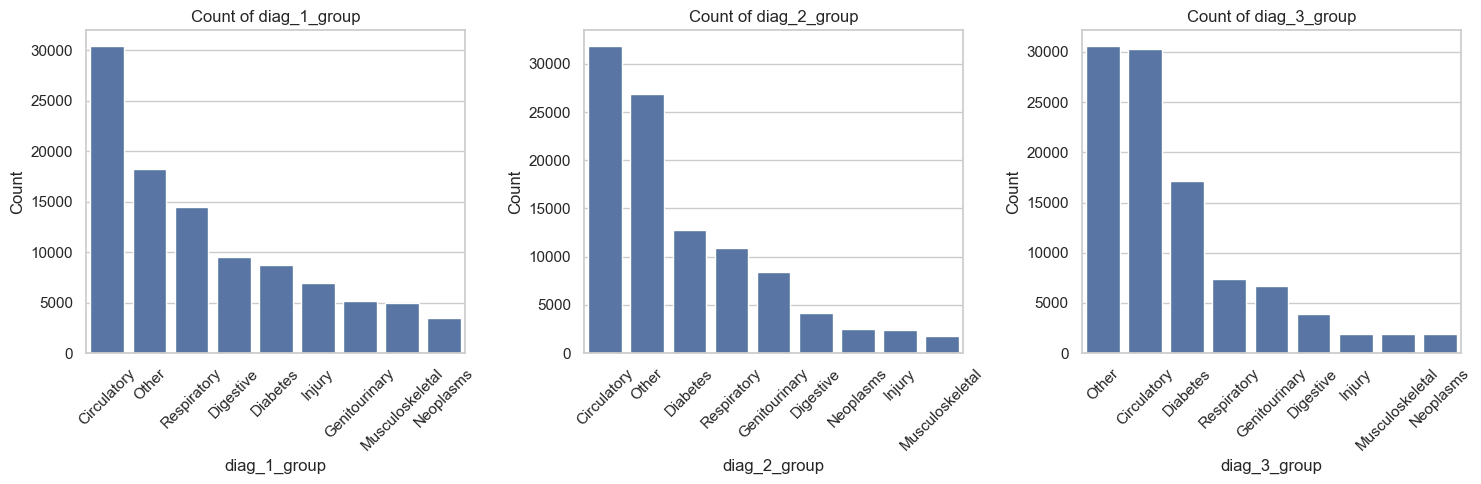

In [269]:
fig = plot_count(idXy, ['diag_1_group', 'diag_2_group', 'diag_3_group'], 1)
save_figure(fig, '01_counts_diagnosis_grouped.png')
plt.show()

In [270]:
# Incorporate KNN rule transforms into idXy before section 6.2 so df = idXy.copy() and
# processed_dataset.csv match the "After" distributions in the figure above.
# NUMERICAL_PREPROCESS_MODEL = "knn"
# idXy, _ = preprocess_numericals_for_model(idXy, NUMERICAL_PREPROCESS_MODEL)


### 6.2 Additional Computed Categories

Collinearity notes for engineered features:
- both_abnormal is derived from a1c_abnormal and glu_abnormal, so it is intentionally redundant.
- total_prior_visits overlaps with number_inpatient, number_emergency, and number_outpatient.
- comorbidity_count summarizes diag_1_group, diag_2_group, and diag_3_group and should be interpreted as an aggregate acuity signal.

In [271]:
# Build modeling dataset from the cleaned dataframe after outlier filtering.
df = idXy.copy()

# Remove discharge outcomes where readmission is not clinically possible.
terminal_or_hospice_ids = {'11', '13', '14', '19', '20', '21'}
rows_before_terminal_filter = len(df)
df = df[
    ~df['discharge_disposition_id'].astype(str).str.strip().isin(terminal_or_hospice_ids)
]
print(
    'Rows removed (terminal/hospice outcomes): '
    f"{rows_before_terminal_filter - len(df)}"
)

# Leakage-safe fallback for repeated patients: keep the earliest encounter.
rows_before_patient_dedup = len(df)
encounter_sort_key = pd.to_numeric(df['encounter_id'], errors='coerce')
df = (
    df.assign(_encounter_sort_key=encounter_sort_key)
      .sort_values('_encounter_sort_key', kind='stable')
      .drop_duplicates(subset=['patient_nbr'], keep='first')
      .drop(columns=['_encounter_sort_key'])
      .copy()
 )
print(
    'Rows removed (repeat patient encounters): '
    f"{rows_before_patient_dedup - len(df)}"
)

# Binary target: 1 if readmitted in <30 days, else 0.
df['readmitted_binary'] = (df['readmitted'].astype(str) == '<30').astype('int8')

# Remove original multiclass target to avoid leakage/confusion.
df = df.drop(columns=['readmitted'])

# Decode clinical IDs using IDS_mapping lookup tables loaded earlier.
def normalize_id(value):
    text = str(value).strip()
    try:
        return str(int(float(text)))
    except ValueError:
        return text


def build_lookup(mapping_df, id_col):
    cleaned = mapping_df[[id_col, 'description']].dropna(subset=[id_col]).copy()
    cleaned[id_col] = cleaned[id_col].apply(normalize_id)
    cleaned['description'] = cleaned['description'].astype(str).str.strip()
    return dict(zip(cleaned[id_col], cleaned['description']))


admission_lookup = build_lookup(admission_type_ids, 'admission_type_id')
discharge_lookup = build_lookup(discharge_disposition_ids, 'discharge_disposition_id')
source_lookup = build_lookup(admission_source_id, 'admission_source_id')

df['admission_type_desc'] = (
    df['admission_type_id'].apply(normalize_id).map(admission_lookup).fillna('Unknown')
)
df['discharge_disposition_desc'] = (
    df['discharge_disposition_id'].apply(normalize_id).map(discharge_lookup).fillna('Unknown')
)
df['admission_source_desc'] = (
    df['admission_source_id'].apply(normalize_id).map(source_lookup).fillna('Unknown')
)

# Encode age brackets as ordinal values rather than continuous midpoints.
age_order = [
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)',
]
age_to_ordinal = {label: idx + 1 for idx, label in enumerate(age_order)}
df['age_ordinal'] = df['age'].astype(str).map(age_to_ordinal).fillna(0).astype('int8')

# -------------------------
# Utilization intensity
# -------------------------
# Aggregate prior utilization into one acuity-oriented signal.
df['total_prior_visits'] = (
    df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
)

stay_days = df['time_in_hospital'].replace(0, np.nan)
df['labs_per_day'] = (df['num_lab_procedures'] / stay_days).fillna(0.0)
df['meds_per_day'] = (df['num_medications'] / stay_days).fillna(0.0)

# -------------------------
# Medication dynamics
# -------------------------
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone',
]
available_meds = [c for c in medication_cols if c in df.columns]

df['num_active_meds'] = (
    (df[available_meds].astype(str) != 'No').sum(axis=1)
).astype('int16')

# Count all dosage changes across the diabetes medication list.
df['total_drug_changes'] = (
    df[available_meds].astype(str).isin(['Up', 'Down']).sum(axis=1)
).astype('int16')

df['any_diabetes_med_change'] = (df['change'].astype(str) == 'Ch').astype('int8')
df['insulin_changed'] = df['insulin'].astype(str).isin(['Up', 'Down']).astype('int8')

# -------------------------
# Consolidate lab risk categories
# -------------------------
# Keep row-wise indicators (fixed: no value_counts misuse).
df['a1c_abnormal'] = df['A1Cresult'].astype(str).isin(['>7', '>8']).astype('int8')
df['glu_abnormal'] = df['max_glu_serum'].astype(str).isin(['>200', '>300']).astype('int8')
df['both_abnormal'] = ((df['a1c_abnormal'] == 1) & (df['glu_abnormal'] == 1)).astype('int8')

# -------------------------
# Grouped admission/discharge/source features
# -------------------------
admission_groups = {
    'emergency_or_trauma': {'1', '7'},
    'urgent': {'2'},
    'elective': {'3'},
    'newborn': {'4'},
}

discharge_groups = {
    'home': {'1', '6', '8'},
    'transfer': {'2', '3', '4', '5', '10', '15', '22', '23', '24', '27', '28', '29', '30'},
    'expired': {'11', '19', '20', '21'},
    'hospice': {'13', '14'},
    'left_ama': {'7'},
    'inpatient': {'9'},
}

source_groups = {
    'er': {'7'},
    'referral': {'1', '2', '3'},
    'transfer': {'4', '5', '6', '10', '18', '22', '25', '26'},
    'newborn': {'11', '12', '13', '14', '23', '24'},
    'home_health_readmit': {'19'},
}


def map_group(code, groups, default='other'):
    code = str(code).strip()
    for label, codes in groups.items():
        if code in codes:
            return label
    return default


df['admission_type_group'] = df['admission_type_id'].astype(str).apply(
    lambda x: map_group(x, admission_groups)
).astype('category')
df['discharge_group'] = df['discharge_disposition_id'].astype(str).apply(
    lambda x: map_group(x, discharge_groups)
).astype('category')
df['admission_source_group'] = df['admission_source_id'].astype(str).apply(
    lambda x: map_group(x, source_groups)
).astype('category')

# Summarize diagnosis burden by counting unique mapped systems per patient.
diag_group_cols = [c for c in ['diag_1_group', 'diag_2_group', 'diag_3_group'] if c in df.columns]
if diag_group_cols:
    def count_unique_non_other(values):
        cleaned = {
            v for v in values
            if v not in {'Other', 'NA', 'nan', 'None'}
        }
        return len(cleaned)

    df['comorbidity_count'] = (
        df[diag_group_cols]
        .astype(str)
        .apply(lambda row: count_unique_non_other(row), axis=1)
        .astype('int8')
    )
else:
    df['comorbidity_count'] = 0

print('Feature engineering complete.')
print(f'Columns after engineering: {df.shape[1]}')
print('readmitted_binary distribution:')
print(df['readmitted_binary'].value_counts(dropna=False).sort_index())


Rows removed (terminal/hospice outcomes): 2423
Rows removed (repeat patient encounters): 29353
Feature engineering complete.
Columns after engineering: 68
readmitted_binary distribution:
readmitted_binary
0    63705
1     6285
Name: count, dtype: int64


In [272]:
idXy['A1Cresult'].value_counts(dropna=False)

A1Cresult
None    84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

## 7. Encode Categorical Variables

In [273]:
# Drop leakage-prone identifiers before encoding/modeling.
id_columns = ['encounter_id', 'patient_nbr']
df = df.drop(columns=[c for c in id_columns if c in df.columns], errors='ignore')

# One-hot encode all remaining categorical predictors except the target.
df = encode_categoricals_wrapper(df, 'readmitted_binary', drop_first=True)

print('Dropped identifier columns before encoding:', id_columns)

Encoded 45 categorical columns.
Shape after encoding: (69990, 2473)
Dropped identifier columns before encoding: ['encounter_id', 'patient_nbr']


In [274]:
# Sanity checks for leakage and engineered features.
leakage_columns_remaining = [c for c in ['encounter_id', 'patient_nbr'] if c in df.columns]
print('Leakage columns still present:', leakage_columns_remaining)

required_engineered = [
    'total_prior_visits',
    'total_drug_changes',
    'a1c_abnormal',
    'glu_abnormal',
    'both_abnormal',
    'comorbidity_count',
]
missing_engineered = [c for c in required_engineered if c not in df.columns]
print('Missing engineered columns:', missing_engineered)

Leakage columns still present: []
Missing engineered columns: []


## 8. Scale Numeric Features

In [275]:
# Keep scaling in the modeling pipeline to avoid leakage and double scaling.
target_column = 'readmitted_binary'
scale_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if c != target_column
]

# Intentionally disabled here: scaling must be fit on training folds only in Notebook 3.
# df, scaler = scale_features(df, scale_cols, method='standard')

print(f'Numeric columns available for scaling in modeling: {len(scale_cols)}')
print('Scaling is deferred to train-only fitting in Notebook 3.')


Numeric columns available for scaling in modeling: 20
Scaling is deferred to train-only fitting in Notebook 3.


## 9. Final Check & Save

In [276]:
print(f'Final shape  : {df.shape}')
print(f'Dtypes:\n{df.dtypes.value_counts()}')
print(f'Missing total: {df.isnull().sum().sum()}')
df.head()

Final shape  : (69990, 2473)
Dtypes:
bool       2452
int64         9
int8          8
float64       2
int16         2
Name: count, dtype: int64
Missing total: 0


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,readmitted_binary,age_ordinal,...,admission_type_group_other,admission_type_group_urgent,discharge_group_inpatient,discharge_group_left_ama,discharge_group_other,discharge_group_transfer,admission_source_group_newborn,admission_source_group_other,admission_source_group_referral,admission_source_group_transfer
8,13,68,2,28,0,0,0,8,0,9,...,False,True,False,False,False,False,False,False,False,True
9,12,33,3,18,0,0,0,8,0,10,...,False,False,False,False,False,True,False,False,False,True
4,1,51,0,8,0,0,0,5,0,5,...,False,False,False,False,False,False,False,False,False,False
10,9,47,2,17,0,0,0,9,0,5,...,False,False,False,False,False,False,False,False,False,False
5,3,31,6,16,0,0,0,9,0,6,...,False,True,False,False,False,False,False,False,True,False


In [278]:
save_processed_data(df, 'processed_dataset.csv')
print('Preprocessing complete. Proceed to Notebook 3 – Modeling.')

Saved processed data to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/data/processed/processed_dataset.csv
Preprocessing complete. Proceed to Notebook 3 – Modeling.
